#### Supp. Fig 4a

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import scanpy as sc  
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib as mpl 
import cell2location 
import pandas as pd
import torch 
import os

pd.set_option('display.max_columns',400)
pd.set_option('display.max_categories',40)
# Set general parameters for publication-ready figures
plt.rcParams.update({
    'pdf.fonttype': 42,
    'font.family': 'Arial',  # Set font to Arial
    'font.size': 14,  # Set font size to at least 14
    'axes.labelsize': 14,  # Axes labels size
    'axes.titlesize': 16,  # Title size for axes
    'xtick.labelsize': 14,  # X-tick label size
    'ytick.labelsize': 14,  # Y-tick label size
    'legend.fontsize': 14,  # Legend font size
    'figure.titlesize': 16,  # Figure title size
    'lines.linewidth': 2,  # Line width for clarity
    'axes.linewidth': 1.5,  # Axis line width
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'text.color': 'black',  # Make sure text is black (not grey)
    'axes.labelcolor': 'black',  # Ensure axes labels are black
    'axes.edgecolor': 'black',  # Ensure edge of axes is black
    'axes.facecolor': 'white',
    'xtick.color': 'black',  # Ensure X-tick marks are black
    'ytick.color': 'black',  # Ensure Y-tick marks are black
    'axes.titlepad': 20  # Padding for title
})

In [10]:
adata_vis = sc.read_h5ad("/Users/jk/Documents/Lab2/visium/python_analysis/local_401/nmf/ann_finest_level/nfact12/h5ad/adata_vis_assigned_cell_types_nfact12.h5ad")


In [11]:
save_dir = "figs"
os.makedirs(save_dir, exist_ok=True)

In [12]:
import seaborn as sns

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_84966/1140849730.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_84966/1140849730.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_84966/1140849730.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_84966/1140849730.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

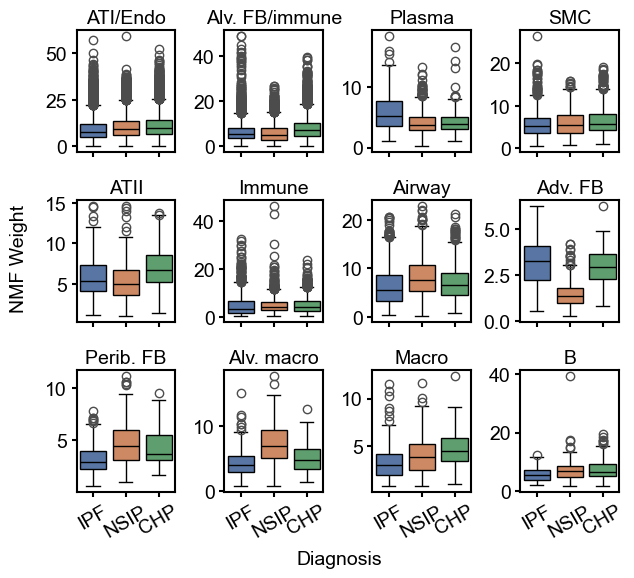

In [ ]:
boxprops=dict(edgecolor="black")
whiskerprops=dict(color="black")
capprops=dict(color='black')
medianprops=dict(color='black')
    
fig, ax = plt.subplots(3, 4, figsize = (7,6))
ax = ax.flatten()
for i, niche in enumerate(['ATI/Endo','Alv. FB/immune','Plasma','SMC','ATII','Immune','Airway','Adv. FB', 'Perib. FB', 'Alv. macro', 'Macro', 'B']):
    
    sns.boxplot(
        data=adata_vis[adata_vis.obs['factor_assigned'] == niche].obs,
        order = ["IPF","NSIP","CHP"],
        x='cond',
        y=niche,
        palette='deep',
        ax = ax[i],
        boxprops=boxprops, whiskerprops=whiskerprops, medianprops=medianprops,capprops=dict(color="black")
    )
    ax[i].set_title(niche, pad = 5, fontsize = 14)
    ax[i].set_xlabel("")
    ax[i].set_ylabel("")
    for label in ax[i].get_xticklabels():
        label.set_rotation(30)          # or 90
        label.set_verticalalignment('top')  # or 'center', 'bottom'
        label.set_y(0)    

for i in range(12):
    ax[i].set_ylabel("")

for i in range(8):
    ax[i].set_xticklabels([])


# Remove any empty subplots 
#ax[-1].set_visible(False)

plt.subplots_adjust(hspace = 0.4, wspace = 0.5)
fig.text(0.5, -0.01, 'Diagnosis', ha='center', fontsize=14)
fig.text(0.03, 0.5, 'NMF Weight', va='center', rotation='vertical', fontsize=14)
#plt.tight_layout(wspace = 0)
plt.savefig(os.path.join(save_dir,"NMF_weights_per_niche_by_cond_averaged.pdf"), bbox_inches = 'tight', transparent = True)
plt.show()
